## Comparing the PCA workflow to Burns' weighted log-odds method

This notebook is a scratch comparison between our existing PCA + logistic-regression "speechiness" score (`ccc2026.run_training`/`rolling_samples`) and the weighted log-odds "dialogism" method used by Patrick Burns in ["Measuring Dialogism in Latin Epic"](https://doi.org/10.1163/9789004750227_010), which we're aiming to replicate for Greek epic.

Burns' method (itself based on Monroe, Colaresi & Quinn 2008, "Fightin' Words", as implemented in the R package `tidylo`) ranks features by a **weighted log-odds ratio with an uninformative Dirichlet prior** rather than by PCA. The functions below are a first Python port of that method, defined here rather than in `src/ccc2026` since this is still a comparison/proof-of-concept — if it supersedes the PCA workflow as intended, it should move into the package.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import ccc2026

tokens = ccc2026.tokens

# Narratological groups (same definition used throughout the package)
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

### Weighted log-odds ratio

For each value of a feature column (lemma, POS tag, or morph tag), this computes a z-score: the log-odds ratio of speech vs. narrative, weighted by an uninformative Dirichlet prior. Following Monroe et al. (2008) and `tidylo`'s default ("uninformative") prior, the prior pseudo-count for a feature value is its own marginal (background) frequency across both narrative and speech combined &mdash; not a single hand-picked constant for every feature, which is what made our earlier `prop` formula sensitive to rare words.

Dividing the log-odds ratio (`delta`) by its own standard error (giving `z`) is what suppresses noise from rare features: a rare feature's ratio gets divided by a large standard error, pulling it back toward zero even if the raw ratio looks extreme.

In [2]:
def weighted_log_odds(col):
    '''Weighted log-odds ratio (speech vs. narrative) for every value of `col`,
    weighted by an uninformative Dirichlet prior (Monroe, Colaresi & Quinn 2008),
    following the same method used by Burns 2026 via the R package tidylo.
    '''

    # explode handles both scalar columns (lemma, pos) and list columns (morph)
    exploded = tokens[col].explode().dropna()
    is_nar = nr_mask.loc[exploded.index]
    is_spk = sp_mask.loc[exploded.index]

    y_nar = exploded[is_nar].value_counts()
    y_spk = exploded[is_spk].value_counts()
    counts = pd.DataFrame({"y_nar": y_nar, "y_spk": y_spk}).fillna(0)

    # uninformative Dirichlet prior: each feature's prior pseudo-count is its
    # own marginal (background) frequency across both groups combined
    alpha = counts["y_nar"] + counts["y_spk"]
    alpha0 = alpha.sum()
    n_nar = counts["y_nar"].sum()
    n_spk = counts["y_spk"].sum()

    omega_nar = (counts["y_nar"] + alpha) / (n_nar + alpha0 - counts["y_nar"] - alpha)
    omega_spk = (counts["y_spk"] + alpha) / (n_spk + alpha0 - counts["y_spk"] - alpha)

    delta = np.log(omega_spk) - np.log(omega_nar)
    variance = 1 / (counts["y_spk"] + alpha) + 1 / (counts["y_nar"] + alpha)
    z = delta / np.sqrt(variance)

    return pd.DataFrame({
        "count_nar": counts["y_nar"],
        "count_spk": counts["y_spk"],
        "delta": delta,
        "z": z,
    }).sort_values("z", ascending=False)

In [3]:
lemma_wlo = weighted_log_odds("lemma")

print("most speech-like lemmas:")
display(lemma_wlo.head(10))

print("most narrative-like lemmas:")
display(lemma_wlo.tail(10))

most speech-like lemmas:


,count_nar,count_spk,delta,z
lemma,,,,
ἐγώ,52.0,3526.0,0.787847,38.615858
σύ,65.0,3217.0,0.779405,36.634020
ἄν,254.0,1273.0,0.564369,18.620624
ἐμός,4.0,808.0,0.797158,18.569839
οὐ,876.0,2134.0,0.393158,18.498009
τίς,696.0,1816.0,0.411809,17.676100
εἰ,281.0,1209.0,0.533107,17.432953
νῦν,144.0,920.0,0.607562,16.648050
εἰμί,1172.0,2156.0,0.310111,15.417708


most narrative-like lemmas:


,count_nar,count_spk,delta,z
lemma,,,,
ῥʼ,354.0,55.0,-0.387848,-6.588111
πούς,610.0,160.0,-0.285275,-6.724181
φημί,847.0,259.0,-0.248966,-7.056982
πρόσφημι,230.0,1.0,-0.577071,-7.168970
ἕ,1324.0,495.0,-0.197153,-7.197459
ἀμφί,794.0,198.0,-0.296821,-7.932186
ὡς,2425.0,897.0,-0.200760,-9.902433
ἄρα,2133.0,416.0,-0.349032,-14.871266
ὁ,6709.0,2571.0,-0.193844,-15.992080


### Lexicons and composite dialogism score

Following Burns' "Methods" section: scale each ranked feature list to [0, 1] (closer to 1 = more speech-like) to produce a lexicon. Build one lexicon from lemmas (the lexical lexicon) and one combining POS and morph tags (the grammatical lexicon, matching how the package already treats POS+morph as the "grammatical" feature classes elsewhere).

Per token: the lexical score is the lemma's lexicon value (0 if out-of-vocabulary); the grammatical score is the mean of the lexicon values for the token's POS tag and all of its morph tags. The composite "dialogism" score is the average of the two.

In [4]:
def make_lexicon(wlo):
    '''Scale a weighted_log_odds table's z-scores to [0, 1] (1 = most speech-like)'''
    z = wlo["z"]
    return (z - z.min()) / (z.max() - z.min())

lex_lemma = make_lexicon(weighted_log_odds("lemma"))
lex_grammar = pd.concat([
    make_lexicon(weighted_log_odds("pos")),
    make_lexicon(weighted_log_odds("morph")),
])

# lexical score: lemma's lexicon value, 0 if out-of-vocabulary
lexical_score = tokens["lemma"].map(lex_lemma).fillna(0)

# grammatical score: mean of the POS tag + all morph tags' lexicon values
def grammar_score_for_row(pos, morph):
    vals = []
    if pd.notna(pos) and pos in lex_grammar.index:
        vals.append(lex_grammar[pos])
    if isinstance(morph, list):
        vals.extend(lex_grammar[m] for m in morph if m in lex_grammar.index)
    return np.mean(vals) if vals else np.nan

grammatical_score = tokens.apply(lambda row: grammar_score_for_row(row["pos"], row["morph"]), axis=1)

# composite dialogism score per token
dialogism = pd.concat(
    [lexical_score.rename("lex"), grammatical_score.rename("gram")], axis=1
).mean(axis=1, skipna=True)

dialogism.describe()

count    429774.000000
mean          0.392374
std           0.120016
min           0.086293
25%           0.322335
50%           0.361753
75%           0.417210
max           0.898011
dtype: float64

### Rolling dialogism score vs. the PCA + logistic regression score

Burns uses a rolling window of 50 tokens for his narrative plot (Figure 9.4); our existing `rolling_samples` defaults to 500. To compare fairly, both methods need to use the *same* window size — so the cell below recomputes the PCA score at each window size tested, rather than reusing a single fixed-window PCA score.

In [5]:
# existing PCA + logistic regression speechiness score, for comparison
feature_set = {
    "lemma": ccc2026.top_lemmas,
    "pos": ccc2026.all_pos,
    "morph": ccc2026.top_morph,
}
train = ccc2026.run_training(feature_set)

In [6]:
for window in [50, 200, 500, 1000]:
    dialogism_roll = dialogism.rolling(
        window=window, center=True, min_periods=int(window * 0.7)
    ).mean()

    # PCA score recomputed at the same window, so the comparison is apples-to-apples
    pca_score = ccc2026.rolling_samples(train, window_size=window)["speech_score"]["score"]

    both = pd.DataFrame({"dialogism": dialogism_roll, "pca": pca_score}).dropna()
    print(
        f"window={window}: n={len(both)}, "
        f"pearson r={both['dialogism'].corr(both['pca']):.3f}, "
        f"spearman r={both['dialogism'].corr(both['pca'], method='spearman'):.3f}"
    )

window=50: n=429755, pearson r=0.879, spearman r=0.871
window=200: n=429695, pearson r=0.902, spearman r=0.901
window=500: n=429575, pearson r=0.898, spearman r=0.893
window=1000: n=429375, pearson r=0.884, spearman r=0.879


Agreement is strong and stable across window sizes once both methods use the same window (Pearson r &asymp; 0.88&ndash;0.90 from 50 to 1000 tokens) &mdash; confirming the intuition that the two methods are largely measuring the same thing. The scatter plot below uses window=500 as a representative case.

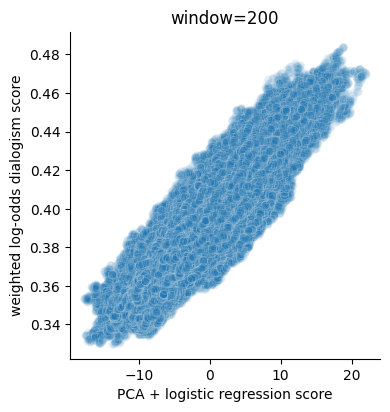

In [18]:
window = 200
dialogism_roll = dialogism.rolling(
    window=window, center=True, min_periods=int(window * 0.7)
).mean()
pca_score = ccc2026.rolling_samples(train, window_size=window)["speech_score"]["score"]
both = pd.DataFrame({"dialogism": dialogism_roll, "pca": pca_score}).dropna()

g = sns.relplot(data=both, x="pca", y="dialogism", alpha=0.1, height=4)
g.set(
    xlabel="PCA + logistic regression score",
    ylabel="weighted log-odds dialogism score",
    title=f"window={window}",
)
plt.show()

### Overlay for a single book

Both scores standardized (z-scored) so they're visually comparable on one axis, for Iliad 1.

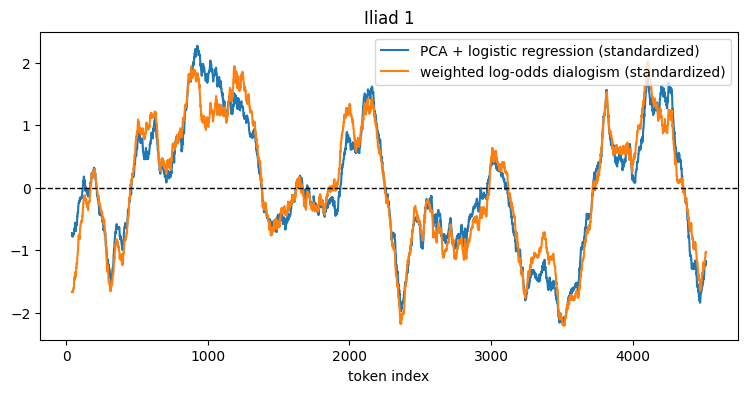

In [19]:
work, pref = "Iliad", "1"
mask = (tokens["work"] == work) & (tokens["pref"] == pref)
idx = tokens.index[mask]

book = pd.DataFrame({
    "dialogism": dialogism_roll.loc[idx],
    "pca": pca_score.reindex(idx),
    "line": tokens.loc[idx, "line"],
}).dropna()

# standardize both scores so they're comparable on one axis
book["dialogism_z"] = (book["dialogism"] - book["dialogism"].mean()) / book["dialogism"].std()
book["pca_z"] = (book["pca"] - book["pca"].mean()) / book["pca"].std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(book.index, book["pca_z"], label="PCA + logistic regression (standardized)")
ax.plot(book.index, book["dialogism_z"], label="weighted log-odds dialogism (standardized)")
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_title(f"{work} {pref}")
ax.set_xlabel("token index")
ax.legend()
plt.show()